# **EDA — Car Price Dataset**

## Objectives

* Perform exploratory data analysis on the cleaned car price dataset
* Identify correlations between car attributes and price
* Formulate and test business hypotheses
* Create visualisations to communicate key insights



## Inputs
* outputs/datasets/cleaned/car_prices_cleaned.csv

## Outputs

* Visualisations saved to outputs/figures/
* Hypothesis testing results

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/tildeholmqvist/Documents/VS_Code_Tilde/DA_project_2/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/tildeholmqvist/Documents/VS_Code_Tilde/DA_project_2'

---

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('outputs/datasets/cleaned/car_prices_cleaned.csv')
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,CarBrand,price_per_horsepower,price_per_enginesize
0,1,3,alfa-romero giulia,gas,std,2,convertible,rwd,front,88.6,...,2.68,9.0,111,5000,21,27,13495.0,alfa-romero,121.576577,103.807692
1,2,3,alfa-romero stelvio,gas,std,2,convertible,rwd,front,88.6,...,2.68,9.0,111,5000,21,27,16500.0,alfa-romero,148.648649,126.923077
2,3,1,alfa-romero Quadrifoglio,gas,std,2,hatchback,rwd,front,94.5,...,3.47,9.0,154,5000,19,26,16500.0,alfa-romero,107.142857,108.552632
3,4,2,audi 100 ls,gas,std,4,sedan,fwd,front,99.8,...,3.40,10.0,102,5500,24,30,13950.0,audi,136.764706,127.981651
4,5,2,audi 100ls,gas,std,4,sedan,4wd,front,99.4,...,3.40,8.0,115,5500,18,22,17450.0,audi,151.739130,128.308824


# Section 2 — Business Hypotheses

1. Engine size and horsepower are the strongest predictors of car price
   — I expect both to show strong positive correlation with price, 
   but want to determine which is the stronger predictor.
   I will also examine the correlation between engine size and 
   horsepower themselves to understand their relationship.

2. Luxury car brands (BMW, Porsche, Jaguar) have significantly 
   higher prices than economy brands
   — Brand perception and reputation directly influences pricing

3. Diesel cars have higher prices than petrol (gas) cars
   — Diesel engines are less common in the US market and 
   typically offer higher torque and fuel efficiency, 
   which may be reflected in a higher purchase price

4. Car body style significantly influences price
   — Convertibles and hardtops are expected to be more expensive 
   than sedans and hatchbacks

---

# Section 3 — Hypothesis Testing
### Hypothesis 1: Engine size and horsepower are the strongest predictors of car price

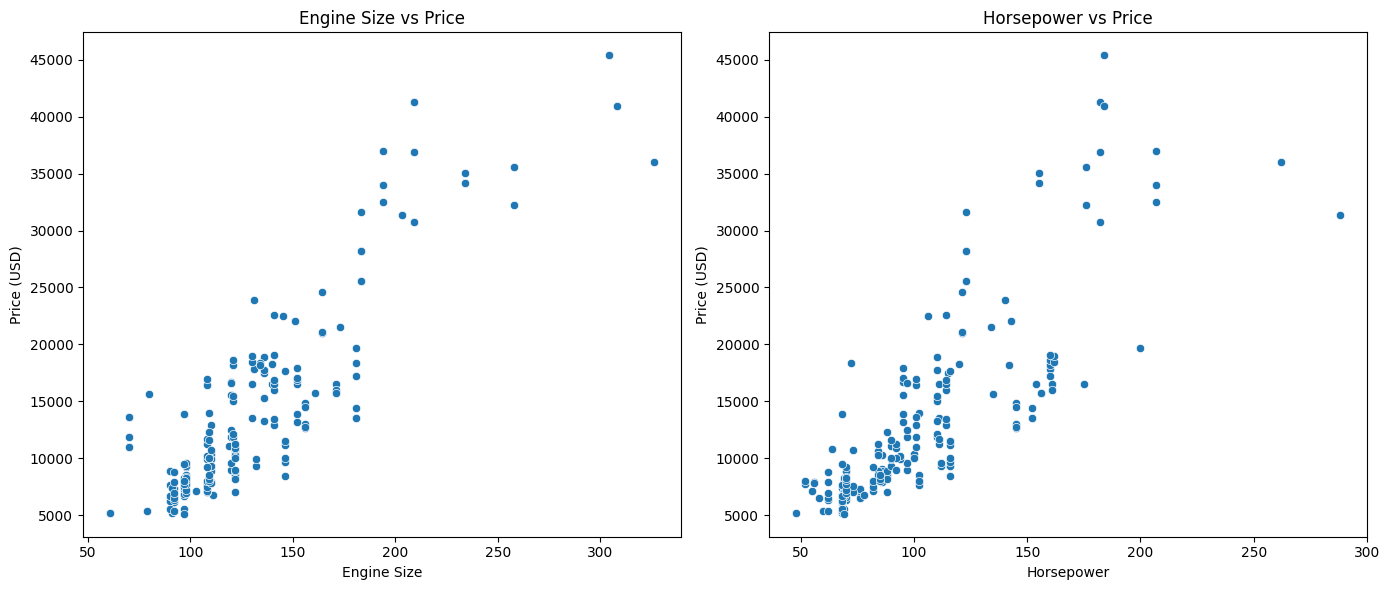

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=df, x='enginesize', y='price', ax=axes[0])
axes[0].set_title('Engine Size vs Price')
axes[0].set_xlabel('Engine Size')
axes[0].set_ylabel('Price (USD)')

sns.scatterplot(data=df, x='horsepower', y='price', ax=axes[1])
axes[1].set_title('Horsepower vs Price')
axes[1].set_xlabel('Horsepower')
axes[1].set_ylabel('Price (USD)')

plt.tight_layout()
plt.show()

In [6]:
import plotly.express as px

fig = px.scatter(df, x='enginesize', y='price', 
                 title='Engine Size vs Price',
                 labels={'enginesize': 'Engine Size', 'price': 'Price (USD)'},
                 hover_data=['CarBrand', 'CarName'])
fig.show()

fig2 = px.scatter(df, x='horsepower', y='price',
                  title='Horsepower vs Price', 
                  labels={'horsepower': 'Horsepower', 'price': 'Price (USD)'},
                  hover_data=['CarBrand', 'CarName'])
fig2.show()